# 3D-CNN benchmark: ROC & precision–recall (multi-seed overlay)

Protein-level score = **max** of per-residue `prob` within each accession; labels: enzyme = 1, non-enzyme = 0.

Edit **`PAIRS`** (or `RESULTS_BASE` + `STAMP`) to point at your `bench_enzyme_*.csv` / `bench_nonenzyme_*.csv` paths. Three seeds are drawn as three curves on **one** ROC panel and **one** PR panel.

In [21]:
%matplotlib inline

import csv
from pathlib import Path
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

In [22]:
def max_prob_per_acc(path: str) -> dict:
    m = {}
    with open(path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            acc = row["accession"]
            p = float(row["prob"])
            o = m.get(acc)
            if o is None or p > o:
                m[acc] = p
    return m


def protein_level_arrays(enz_path: str, non_path: str) -> Tuple[np.ndarray, np.ndarray, int, int]:
    enz = max_prob_per_acc(enz_path)
    non = max_prob_per_acc(non_path)
    y_true = np.array([1] * len(enz) + [0] * len(non), dtype=np.int8)
    y_score = np.array(list(enz.values()) + list(non.values()), dtype=np.float64)
    return y_true, y_score, len(enz), len(non)


def protein_level_auroc_auprc(enz_path: str, non_path: str) -> Tuple[float, float, int, int]:
    y_true, y_score, n_e, n_n = protein_level_arrays(enz_path, non_path)
    return (
        float(roc_auc_score(y_true, y_score)),
        float(average_precision_score(y_true, y_score)),
        n_e,
        n_n,
    )


def plot_roc_prc_overlay(
    pairs: List[Tuple[str, str, str]],
    title: str = "Enzyme vs non-enzyme (protein-level max residue prob)",
    save_path=None,
):
    """One figure: left = ROC, right = PR; one curve per --pair (same labels as seeds)."""
    colors = ["#2563EB", "#059669", "#D97706", "#7C3AED", "#DC2626"]
    fig, (ax_roc, ax_pr) = plt.subplots(
        1,
        2,
        figsize=(12, 5.2),
        dpi=150,
        gridspec_kw={"width_ratios": [1, 1], "wspace": 0.28},
    )

    y0, _, _, _ = protein_level_arrays(pairs[0][1], pairs[0][2])
    prevalence = float(np.mean(y0))

    aurocs_list, auprcs_list = [], []
    for i, (seed_label, enz_p, non_p) in enumerate(pairs):
        y_true, y_score, _, _ = protein_level_arrays(enz_p, non_p)
        auroc = roc_auc_score(y_true, y_score)
        auprc = average_precision_score(y_true, y_score)
        aurocs_list.append(float(auroc))
        auprcs_list.append(float(auprc))
        fpr, tpr, _ = roc_curve(y_true, y_score)
        prec, rec, _ = precision_recall_curve(y_true, y_score)
        c = colors[i % len(colors)]
        ax_roc.plot(
            fpr, tpr, color=c, lw=2,
            label=f"seed {seed_label} (AUROC = {auroc:.4f})",
        )
        ax_pr.plot(
            rec, prec, color=c, lw=2,
            label=f"seed {seed_label} (AUPRC = {auprc:.4f})",
        )

    ax_roc.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.45, label="chance")
    ax_roc.set_xlabel("False positive rate")
    ax_roc.set_ylabel("True positive rate")
    ax_roc.set_title("ROC")
    ax_roc.set_xlim(-0.02, 1.02)
    ax_roc.set_ylim(-0.02, 1.02)
    ax_roc.legend(loc="lower right", fontsize=8, framealpha=0.92)
    ax_roc.grid(True, linestyle=":", alpha=0.45)

    ax_pr.axhline(prevalence, color="k", linestyle="--", lw=1, alpha=0.45, label=f"random (P = {prevalence:.4f})")
    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.set_title("PRC")
    ax_pr.set_xlim(-0.02, 1.02)
    ax_pr.set_ylim(-0.02, 1.02)
    ax_pr.legend(loc="lower left", fontsize=8, framealpha=0.92)
    ax_pr.grid(True, linestyle=":", alpha=0.45)

    au = np.array(aurocs_list, dtype=np.float64)
    ap = np.array(auprcs_list, dtype=np.float64)
    n_seeds = len(au)
    std_au = float(au.std(ddof=1)) if n_seeds > 1 else 0.0
    std_ap = float(ap.std(ddof=1)) if n_seeds > 1 else 0.0
    stats_line = (
        f"mean ± std  AUROC: {float(au.mean()):.4f} ± {std_au:.4f}    "
        f"AUPRC: {float(ap.mean()):.4f} ± {std_ap:.4f}    (n_seeds = {n_seeds})"
    )

    fig.suptitle(title, fontsize=11, y=1.02)
    fig.text(
        0.5,
        0.965,
        stats_line,
        ha="center",
        fontsize=10,
        transform=fig.transFigure,
    )
    fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.88])
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", pad_inches=0.25)
        print("Saved:", save_path)
    print(stats_line)
    return fig, (ax_roc, ax_pr)

## Configure CSV paths (three seeds)

Each entry: `(seed_label, path_to_bench_enzyme_csv, path_to_bench_nonenzyme_csv)`.

In [23]:
RESULTS_BASE = Path("/data/data3/conglab/s441865/code/Catalytic_sites_setA_3dcnn/results")
STAMP = "20260429_191934_delete"

PAIRS: List[Tuple[str, str, str]] = [
    ("42", str(RESULTS_BASE / "run_seed42" / f"bench_enzyme_{STAMP}.csv"), str(RESULTS_BASE / "run_seed42" / f"bench_nonenzyme_{STAMP}.csv")),
    ("123", str(RESULTS_BASE / "run_seed123" / f"bench_enzyme_{STAMP}.csv"), str(RESULTS_BASE / "run_seed123" / f"bench_nonenzyme_{STAMP}.csv")),
    ("2026", str(RESULTS_BASE / "run_seed2026" / f"bench_enzyme_{STAMP}.csv"), str(RESULTS_BASE / "run_seed2026" / f"bench_nonenzyme_{STAMP}.csv")),
]

FIG_TITLE = "3D-CNN bench — protein-level max(prob)"
SAVE_PNG = RESULTS_BASE / "bench_roc_prc_3seeds_overlay.png"

In [24]:
labels, aurocs, auprcs = [], [], []
rows = []
for seed_label, enz_p, non_p in PAIRS:
    auroc, auprc, n_e, n_n = protein_level_auroc_auprc(enz_p, non_p)
    labels.append(str(seed_label))
    aurocs.append(auroc)
    auprcs.append(auprc)
    rows.append({"seed": seed_label, "n_enz": n_e, "n_non": n_n, "AUROC": auroc, "AUPRC": auprc})
    print(f"seed={seed_label}  n_enz={n_e}  n_non={n_n}  AUROC={auroc:.6f}  AUPRC={auprc:.6f}")

try:
    from pandas import DataFrame

    display(DataFrame(rows))
except Exception:
    for r in rows:
        print(r)

au = np.array(aurocs)
ap = np.array(auprcs)
print(f"\nmean ± std  AUROC: {au.mean():.6f} ± {au.std(ddof=1):.6f}")
print(f"mean ± std  AUPRC: {ap.mean():.6f} ± {ap.std(ddof=1):.6f}")

seed=42  n_enz=927  n_non=2794  AUROC=0.867044  AUPRC=0.645336
seed=123  n_enz=927  n_non=2794  AUROC=0.856121  AUPRC=0.606201
seed=2026  n_enz=927  n_non=2794  AUROC=0.864807  AUPRC=0.659618


,seed,n_enz,n_non,AUROC,AUPRC
0,42,927,2794,0.867044,0.645336
1,123,927,2794,0.856121,0.606201
2,2026,927,2794,0.864807,0.659618



mean ± std  AUROC: 0.862658 ± 0.005770
mean ± std  AUPRC: 0.637052 ± 0.027655


/tmp/ipykernel_178898/4057268103.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.88])


Saved: /data/data3/conglab/s441865/code/Catalytic_sites_setA_3dcnn/results/bench_roc_prc_3seeds_overlay.png
mean ± std  AUROC: 0.8627 ± 0.0058    AUPRC: 0.6371 ± 0.0277    (n_seeds = 3)


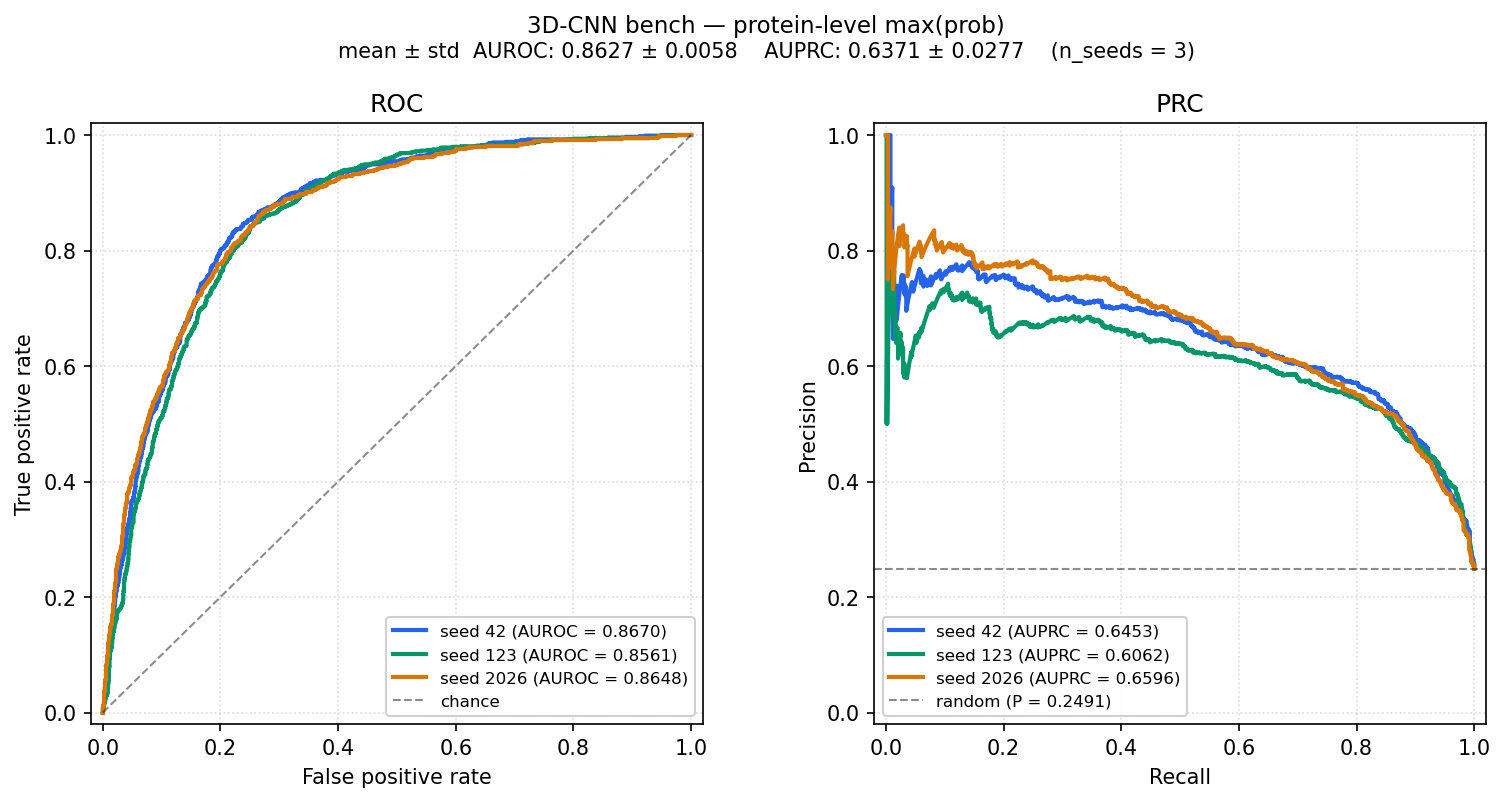

In [25]:
fig, _ = plot_roc_prc_overlay(PAIRS, title=FIG_TITLE, save_path=str(SAVE_PNG))
plt.show()